In [67]:
import pymc as pm, arviz as az, polars as pl

In [68]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/chimpanzees.csv", separator=";").drop("recipient", "trial").rename({"condition":"partner_present"})

In [72]:
df = df.with_columns(
    treatment=pl.col("prosoc_left")+2*pl.col("partner_present"),
    actor=pl.col("actor")-1
)
df.group_by("actor", "treatment").count()

/var/folders/3g/qw0kh7k15n90fnk3l1jxy2d80000gn/T/ipykernel_97645/1561944689.py:5: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  df.group_by("actor", "treatment").count()


actor,treatment,count
i64,i64,u32
5,3,18
1,3,18
3,0,18
1,1,18
4,2,18
…,…,…
5,1,18
0,2,18
0,1,18


In [73]:
with pm.Model(coords={
    "treatment": df["treatment"].unique(),
    "actor": df["actor"].unique(),
}) as base_model:
    alpha = pm.Normal("alpha", mu=0, sigma=1, dims="actor")
    beta = pm.Normal("beta", mu=0, sigma=1, dims="treatment")

    probs = pm.Deterministic("probs", pm.invlogit(alpha[df["actor"].to_numpy()] + beta[df["treatment"].to_numpy()]))

    pulled_left = pm.Bernoulli("pulled_left", logit_p=probs, observed=df["pulled_left"].to_numpy())

    # sample priors
    prior_predictive = pm.sample_prior_predictive(var_names=["pulled_left", "probs"])

    # sample å
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, beta, pulled_left]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [pulled_left]


Output()

Output()

<Axes: >

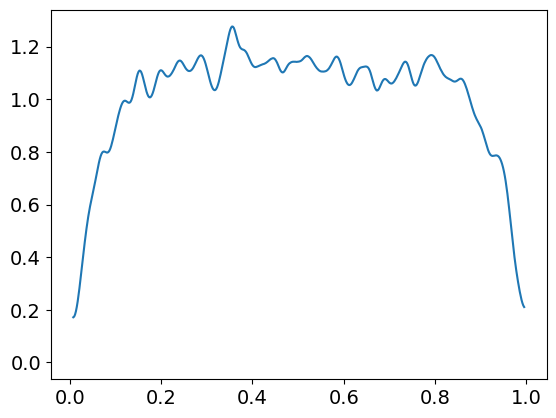

In [74]:
az.plot_dist(prior_predictive.prior["probs"].values.flatten())

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

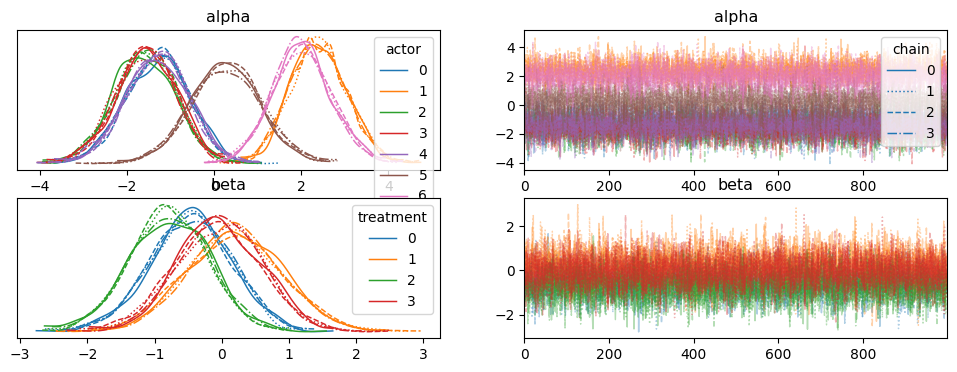

In [75]:
az.plot_trace(posterior, legend=True, var_names=["alpha", "beta"])